04_xgboost_test_1: XGBoost处理类别不平衡 + 300棵树

1. 加载数据...
训练集形状: (700000, 26)

2. 准备数据...
编码后特征数: 42
训练集: (560000, 42), 验证集: (140000, 42)

3. 计算类别权重...
0类(无糖尿)样本数: 210954
1类(有糖尿)样本数: 349046
scale_pos_weight: 0.604

之前的实验 [03_xgboost_test_0 (默认参数)] 结果:
- AUC: 0.7192
- 0类召回率: 0.39
- 1类召回率: 0.85
- 召回率gap: 0.46

4. 训练XGBoost (scale_pos_weight + 300 trees)...
[0]	validation_0-auc:0.68585
[50]	validation_0-auc:0.71273
[100]	validation_0-auc:0.71904
[150]	validation_0-auc:0.72191
[200]	validation_0-auc:0.72372
[250]	validation_0-auc:0.72466
[299]	validation_0-auc:0.72549

5. 模型评估...

当前实验 [04_xgboost_test_1] 结果:
- AUC: 0.7255
- 0类召回率: 0.695
- 1类召回率: 0.631
- 召回率gap: -0.064

对比之前的实验:
- AUC提升: +0.0063
- 召回率gap改善: 0.46 → -0.06

分类报告:
              precision    recall  f1-score   support

         0.0       0.53      0.69      0.60     52739
         1.0       0.77      0.63      0.70     87261

    accuracy                           0.65    140000
   macro avg       0.65      0.66      0.65    140000

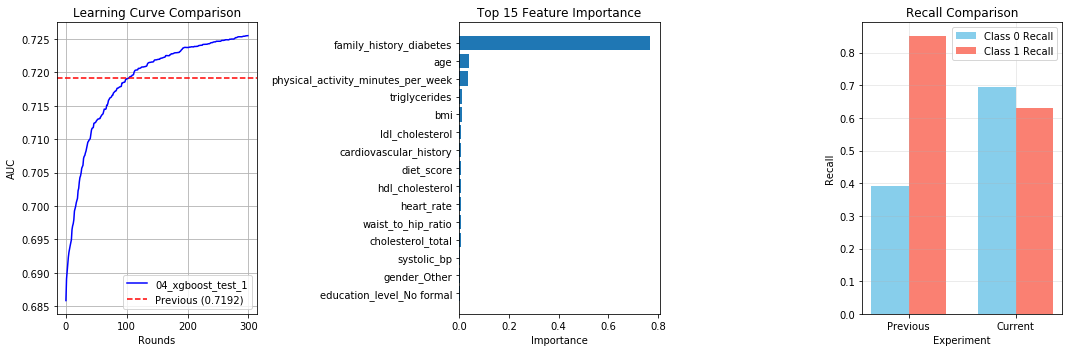


7. 阈值优化分析...

不同阈值下的召回率:
------------------------------------------------------------
阈值         0类召回         1类召回         gap        F1-score(0) F1-score(1)
------------------------------------------------------------
0.3        0.239        0.934        0.695      0.355        0.781       
0.4        0.475        0.810        0.336      0.531        0.762       
0.5        0.695        0.631        -0.064     0.603        0.695       
0.6        0.853        0.434        -0.419     0.611        0.570       
0.7        0.934        0.279        -0.655     0.597        0.423       
------------------------------------------------------------
最佳阈值: 0.5 (平均F1-score: 0.649)

8. 保存模型...
模型已保存到 ../models/04_xgboost_test_1.pkl

9. 生成Kaggle提交文件...
提交文件已保存到 ../submissions/04_xgboost_test_1.csv


In [5]:
# 04_xgboost_test_1.ipynb
# 主要更改：
# 处理类别不平衡
# 树的数量增加到从0~300棵树依次测试

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, recall_score
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("04_xgboost_test_1: XGBoost处理类别不平衡 + 300棵树")
print("="*60)

# 1. 加载数据
print("\n1. 加载数据...")
train = pd.read_csv('../data/train.csv')
print(f"训练集形状: {train.shape}")

# 2. 准备数据
print("\n2. 准备数据...")
X = train.drop(['id', 'diagnosed_diabetes'], axis=1)
y = train['diagnosed_diabetes']

# 编码类别特征
categorical_cols = ['gender', 'ethnicity', 'education_level', 
                   'income_level', 'smoking_status', 'employment_status']
X_encoded = pd.get_dummies(X, columns=categorical_cols)
print(f"编码后特征数: {X_encoded.shape[1]}")

# 分割数据
X_train, X_val, y_train, y_val = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)
print(f"训练集: {X_train.shape}, 验证集: {X_val.shape}")

# 3. 计算类别权重
print("\n3. 计算类别权重...")
n_negative = sum(y_train == 0)
n_positive = sum(y_train == 1)
scale_pos_weight = n_negative / n_positive

print(f"0类(无糖尿)样本数: {n_negative}")
print(f"1类(有糖尿)样本数: {n_positive}")
print(f"scale_pos_weight: {scale_pos_weight:.3f}")

# 4. 之前的实验结果（用于对比）
previous_exp = {
    'name': '03_xgboost_test_0 (默认参数)',
    'auc': 0.7192,
    'recall_0': 0.39,
    'recall_1': 0.85
}

print(f"\n之前的实验 [{previous_exp['name']}] 结果:")
print(f"- AUC: {previous_exp['auc']}")
print(f"- 0类召回率: {previous_exp['recall_0']}")
print(f"- 1类召回率: {previous_exp['recall_1']}")
print(f"- 召回率gap: {previous_exp['recall_1'] - previous_exp['recall_0']:.2f}")

# 5. 训练平衡的XGBoost
print("\n4. 训练XGBoost (scale_pos_weight + 300 trees)...")

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc',
    use_label_encoder=False
)

# 训练并记录过程
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

# 6. 评估
print("\n5. 模型评估...")
y_pred_proba = xgb_model.predict_proba(X_val)[:, 1]
y_pred = xgb_model.predict(X_val)

current_auc = roc_auc_score(y_val, y_pred_proba)

# 计算召回率
recall_0 = recall_score(y_val, y_pred, pos_label=0)
recall_1 = recall_score(y_val, y_pred, pos_label=1)
recall_gap = recall_1 - recall_0

print(f"\n当前实验 [04_xgboost_test_1] 结果:")
print(f"- AUC: {current_auc:.4f}")
print(f"- 0类召回率: {recall_0:.3f}")
print(f"- 1类召回率: {recall_1:.3f}")
print(f"- 召回率gap: {recall_gap:.3f}")

print(f"\n对比之前的实验:")
print(f"- AUC提升: +{current_auc - previous_exp['auc']:.4f}")
print(f"- 召回率gap改善: {previous_exp['recall_1'] - previous_exp['recall_0']:.2f} → {recall_gap:.2f}")

print("\n分类报告:")
print(classification_report(y_val, y_pred))

# 7. 学习曲线分析
print("\n6. 绘制学习曲线...")
results = xgb_model.evals_result()
epochs = len(results['validation_0']['auc'])
x_axis = range(0, epochs)

plt.figure(figsize=(15, 5))

# 学习曲线
plt.subplot(1, 3, 1)
plt.plot(x_axis, results['validation_0']['auc'], 'b-', label='04_xgboost_test_1')
plt.axhline(y=previous_exp['auc'], color='r', linestyle='--', label=f"Previous ({previous_exp['auc']})")
plt.xlabel('Rounds')
plt.ylabel('AUC')
plt.title('Learning Curve Comparison')
plt.legend()
plt.grid(True)

# 特征重要性
plt.subplot(1, 3, 2)
importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.barh(importance['feature'], importance['importance'])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importance')
plt.gca().invert_yaxis()

# 召回率对比
plt.subplot(1, 3, 3)
x_labels = ['Previous', 'Current']
recall_0_values = [previous_exp['recall_0'], recall_0]
recall_1_values = [previous_exp['recall_1'], recall_1]

x = np.arange(len(x_labels))
width = 0.35

plt.bar(x - width/2, recall_0_values, width, label='Class 0 Recall', color='skyblue')
plt.bar(x + width/2, recall_1_values, width, label='Class 1 Recall', color='salmon')
plt.xlabel('Experiment')
plt.ylabel('Recall')
plt.title('Recall Comparison')
plt.xticks(x, x_labels)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../logs/04_xgboost_test_1_plots.png', dpi=100, bbox_inches='tight')
plt.show()

# 8. 不同阈值分析
print("\n7. 阈值优化分析...")
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
print("\n不同阈值下的召回率:")
print("-" * 60)
print(f"{'阈值':<10} {'0类召回':<12} {'1类召回':<12} {'gap':<10} {'F1-score(0)'} {'F1-score(1)'}")
print("-" * 60)

from sklearn.metrics import f1_score

best_threshold = 0.5
best_f1_avg = 0

for thresh in thresholds:
    y_pred_thresh = (y_pred_proba >= thresh).astype(float)
    r0 = recall_score(y_val, y_pred_thresh, pos_label=0)
    r1 = recall_score(y_val, y_pred_thresh, pos_label=1)
    f1_0 = f1_score(y_val, y_pred_thresh, pos_label=0)
    f1_1 = f1_score(y_val, y_pred_thresh, pos_label=1)
    gap = r1 - r0
    f1_avg = (f1_0 + f1_1) / 2
    print(f"{thresh:<10} {r0:<12.3f} {r1:<12.3f} {gap:<10.3f} {f1_0:<12.3f} {f1_1:<12.3f}")
    
    if f1_avg > best_f1_avg:
        best_f1_avg = f1_avg
        best_threshold = thresh

print("-" * 60)
print(f"最佳阈值: {best_threshold} (平均F1-score: {best_f1_avg:.3f})")

# 9. 保存模型
print("\n8. 保存模型...")
model_path = '../models/04_xgboost_test_1.pkl'
joblib.dump(xgb_model, model_path)
print(f"模型已保存到 {model_path}")

# 10. 生成提交文件
print("\n9. 生成Kaggle提交文件...")
test = pd.read_csv('../data/test.csv')
X_test = test.drop(['id'], axis=1)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols)

# 确保列一致
missing_cols = set(X_train.columns) - set(X_test_encoded.columns)
for col in missing_cols:
    X_test_encoded[col] = 0
X_test_encoded = X_test_encoded[X_train.columns]

test_pred = xgb_model.predict_proba(X_test_encoded)[:, 1]

# 使用最佳阈值
test_pred_adjusted = (test_pred >= best_threshold).astype(float)

submission = pd.DataFrame({
    'id': test['id'],
    'diagnosed_diabetes': test_pred  # 用概率值提交，Kaggle通常需要概率
})
submission_path = '../submissions/04_xgboost_test_1.csv'
submission.to_csv(submission_path, index=False)
print(f"提交文件已保存到 {submission_path}")


============================================================
04_xgboost_test_1 Report
============================================================

[Main Change]
- Handling class imbalance
- Increasing the number of trees to test sequentially from 0 to 300 trees.

[Experiment Information]
File Name: 04_xgboost_test_1
Date: 2026-03-15 23:06
Model: XGBoost Classifier

[Parameters]
- n_estimators: 300
- learning_rate: 0.1
- max_depth: 6
- scale_pos_weight: 0.604
- random_state: 42

[Results Comparison with Previous]
Previous Experiment (03_xgboost_test_0):
- AUC: 0.7192
- Class 0 Recall: 0.39
- Class 1 Recall: 0.85
- Recall Gap: 0.46

Current Experiment (04_xgboost_test_1):
- AUC: 0.7255
- Class 0 Recall: 0.695
- Class 1 Recall: 0.631
- Recall Gap: -0.064

[Improvements]
- AUC Improvement: +0.0063
- Gap Improvement: 0.46 → -0.06

[Key Findings]
1. Class Imbalance: FIXED (gap = -0.064)
2. Model Convergence: Converging but still underfit
3. Best Threshold: 0.5 (for balanced F1-score)

[Top 5 Features]
1. family_history_diabetes: 0.768
2. age: 0.038
3. physical_activity_minutes_per_week: 0.033
4. triglycerides: 0.012
5. bmi: 0.009

[Next Steps]
- Try tuning max_depth
- Experiment with different learning rates
- Keep increase the number of tree to 500